In [29]:
!pip install pandas numpy matplotlib seaborn

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
airbnb_data= pd.read_csv("/kaggle/input/datasets/dgomonov/new-york-city-airbnb-open-data/AB_NYC_2019.csv")

airbnb_data.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [32]:
# Read all YouTube datasets into a list of DataFrames
youtube_file_paths = [
    "/kaggle/input/datasets/datasnaek/youtube-new/CAvideos.csv",
    "/kaggle/input/datasets/datasnaek/youtube-new/DEvideos.csv",
    "/kaggle/input/datasets/datasnaek/youtube-new/FRvideos.csv",
    "/kaggle/input/datasets/datasnaek/youtube-new/GBvideos.csv",
    "/kaggle/input/datasets/datasnaek/youtube-new/INvideos.csv",
    "/kaggle/input/datasets/datasnaek/youtube-new/JPvideos.csv",
    "/kaggle/input/datasets/datasnaek/youtube-new/KRvideos.csv",
    "/kaggle/input/datasets/datasnaek/youtube-new/MXvideos.csv",
    "/kaggle/input/datasets/datasnaek/youtube-new/RUvideos.csv",
    "/kaggle/input/datasets/datasnaek/youtube-new/USvideos.csv"
]

youtube_dataframes = [pd.read_csv(file_path,encoding='ISO-8859-1') for file_path in youtube_file_paths]

youtube_data = pd.concat(youtube_dataframes, ignore_index=True)

youtube_data.head()    

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,n1WpP7iowLc,17.14.11,Eminem - Walk On Water (Audio) ft. BeyoncÃ©,EminemVEVO,10,2017-11-10T17:00:03.000Z,"Eminem|""Walk""|""On""|""Water""|""Aftermath/Shady/In...",17158579,787425,43420,125882,https://i.ytimg.com/vi/n1WpP7iowLc/default.jpg,False,False,False,Eminem's new track Walk on Water ft. BeyoncÃ© ...
1,0dBIkQ4Mz1M,17.14.11,PLUSH - Bad Unboxing Fan Mail,iDubbbzTV,23,2017-11-13T17:00:00.000Z,"plush|""bad unboxing""|""unboxing""|""fan mail""|""id...",1014651,127794,1688,13030,https://i.ytimg.com/vi/0dBIkQ4Mz1M/default.jpg,False,False,False,STill got a lot of packages. Probably will las...
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146035,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO â¶ \n\nSUBSCRIBE âº ...
3,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095828,132239,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...
4,2Vv-BfVoq4g,17.14.11,Ed Sheeran - Perfect (Official Music Video),Ed Sheeran,10,2017-11-09T11:04:14.000Z,"edsheeran|""ed sheeran""|""acoustic""|""live""|""cove...",33523622,1634130,21082,85067,https://i.ytimg.com/vi/2Vv-BfVoq4g/default.jpg,False,False,False,ð§: https://ad.gt/yt-perfect\nð°: https://...


In [33]:
# Check for integrity of Airbnb dataset
print("Airbnb Dataset Info:")
print(airbnb_data.info())

print("\nYouTube Dataset Info:")
print(youtube_data.info())

Airbnb Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review

In [34]:
# Check for missing data in Airbnb dataset
missing_values = airbnb_data.isnull().sum()
print("Missing values in Airbnb Dataset:", missing_values)

# Print the columns of the Airbnb DataFrame to verify the names
print("Columns in Airbnb DataFrame:", airbnb_data.columns)

# Fill missing values for reviews_per_month based on context
airbnb_data['last_review'] = airbnb_data['last_review'].fillna(airbnb_data['last_review'].mode()[0])

# Drop rows where 'neighbourhood_group' is not found
airbnb_data.drop(columns=['neighbourhood_group'], inplace=True, errors='ignore')

# Check for missing data in YouTube dataset
missing_youtube = youtube_data.isnull().sum()
print("Missing values in YouTube Dataset:", missing_youtube)

# Fill or drop missing values based on analysis
youtube_data['description'] = youtube_data['description'].fillna('No description')

Missing values in Airbnb Dataset: id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64
Columns in Airbnb DataFrame: Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_3

In [36]:
# Standardize column names for consistency
airbnb_data.columns = airbnb_data.columns.str.lower().str.replace(' ', '_')
youtube_data.columns = youtube_data.columns.str.lower().str.replace(' ', '_')

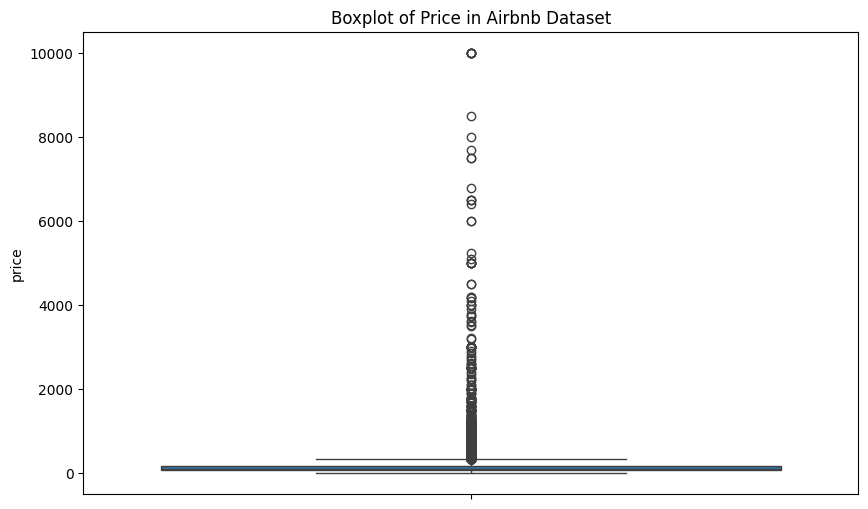

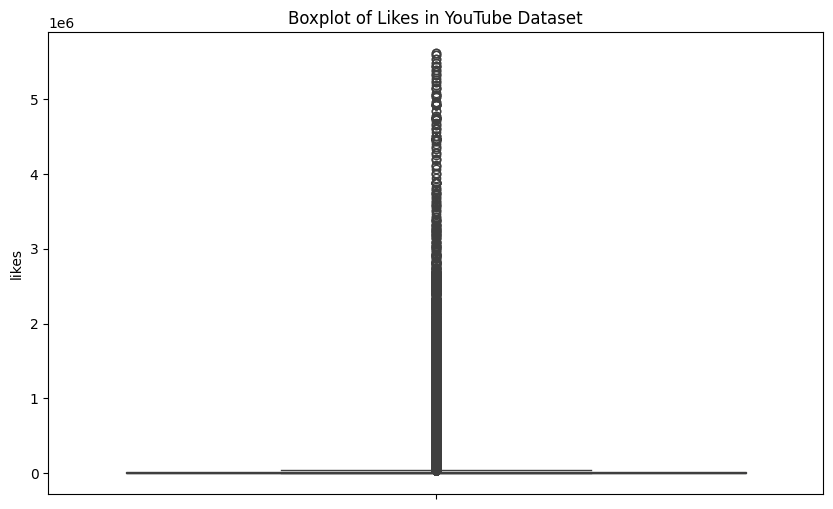

In [37]:
# Visualize outliers for the price in the Airbnb dataset using boxplot
plt.figure(figsize=(10,6))
sns.boxplot(airbnb_data['price'])
plt.title("Boxplot of Price in Airbnb Dataset")
plt.show()

# Remove outliers in Airbnb dataset (assuming price is normally distributed)
q1 = airbnb_data['price'].quantile(0.25)
q3 = airbnb_data['price'].quantile(0.75)
iqr = q3 - q1

airbnb_data = airbnb_data[
    (airbnb_data['price'] >= (q1 - 1.5 * iqr)) &
    (airbnb_data['price'] <= (q3 + 1.5 * iqr))
]

# Visualize outliers for likes in YouTube dataset
plt.figure(figsize=(10,6))
sns.boxplot(youtube_data['likes'])
plt.title("Boxplot of Likes in YouTube Dataset")
plt.show()

# Remove outliers in YouTube dataset
q1 = youtube_data['likes'].quantile(0.25)
q3 = youtube_data['likes'].quantile(0.75)
iqr = q3 - q1

youtube_data = youtube_data[
    (youtube_data['likes'] >= (q1 - 1.5 * iqr)) &
    (youtube_data['likes'] <= (q3 + 1.5 * iqr))
]

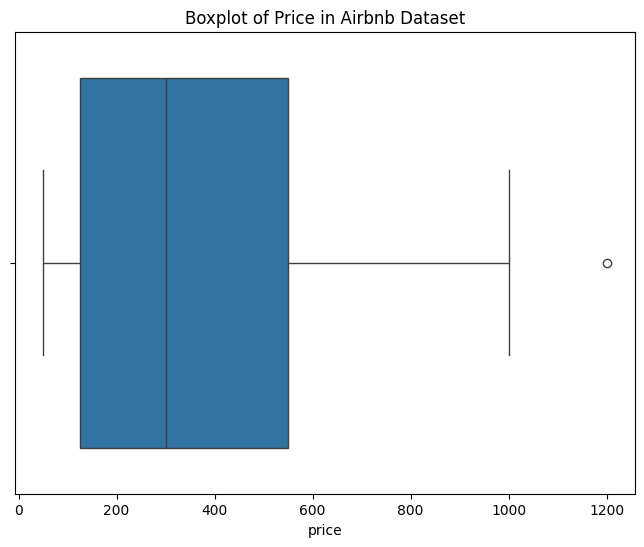

/tmp/ipykernel_55/2811809514.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df["cluster"] = kmeans.fit_predict(feature_scaled)


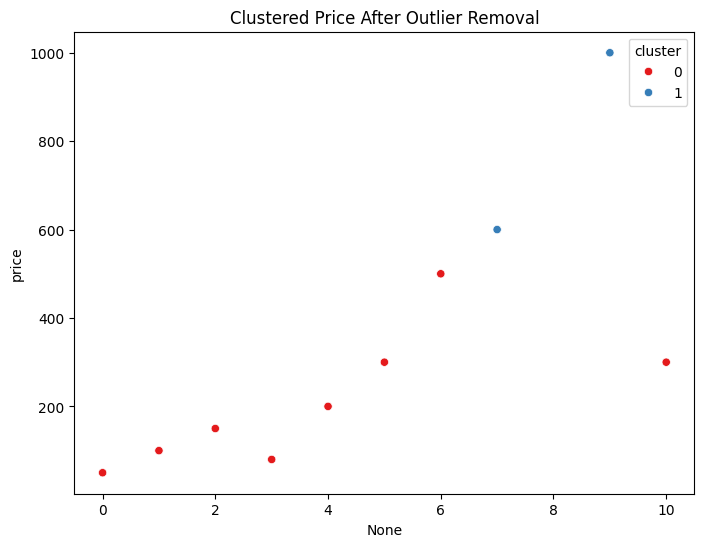

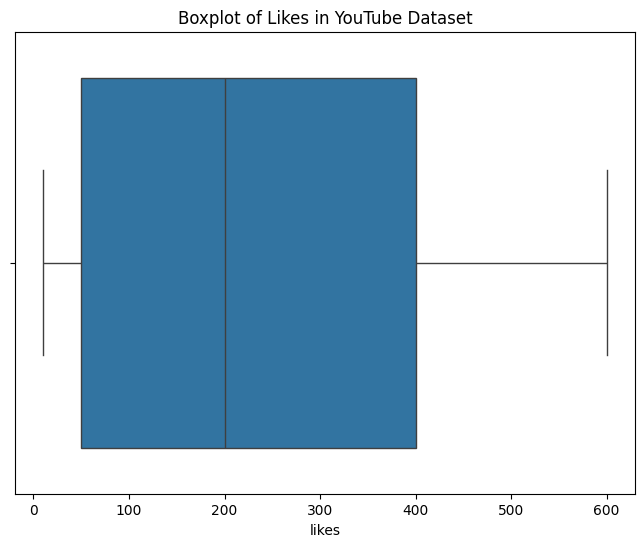

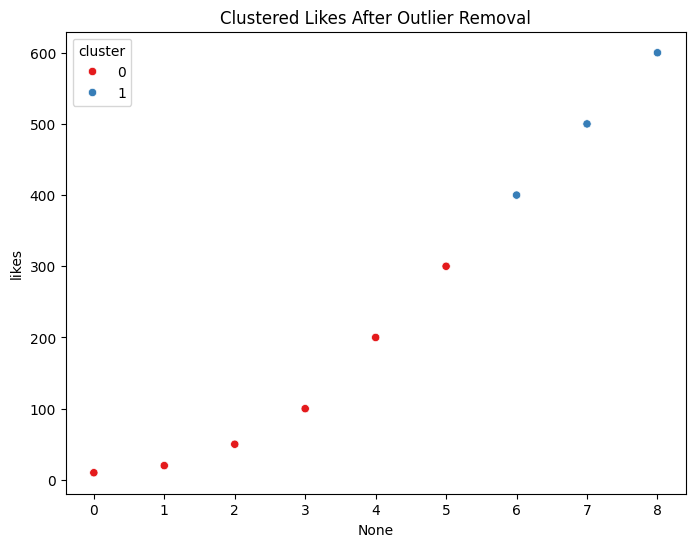

In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Sample Airbnb dataset (replace with your own data)
airbnb_data = pd.DataFrame({
    "price": [50, 100, 150, 80, 200, 300, 500, 600, 1200, 1000, 300],
    "other_feature": [1, 2, 1.5, 3, 2.5, 4, 5, 3.5, 6, 4.5, 2]
})

# Sample YouTube dataset (replace with your own data)
youtube_data = pd.DataFrame({
    "likes": [10, 20, 50, 100, 200, 300, 400, 500, 600],
    "other_feature": [1, 1.2, 1.4, 1.6, 1.8, 2, 2.2, 2.4, 2.6]
})

def visualize_and_remove_outliers(df, feature, dataset_name):

    # Visualize outliers using boxplot
    plt.figure(figsize=(8,6))
    sns.boxplot(x=df[feature])
    plt.title(f"Boxplot of {feature.capitalize()} in {dataset_name} Dataset")
    plt.show()

    # Calculate Q1 and Q3
    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)

    # Calculate IQR
    iqr = q3 - q1

    # Define outlier limits
    filtered_df = df[(df[feature] >= (q1 - 1.5 * iqr)) &
                     (df[feature] <= (q3 + 1.5 * iqr))]

    # Standardize column
    scaler = StandardScaler()
    feature_scaled = scaler.fit_transform(filtered_df[[feature]])

    # Apply KMeans clustering
    kmeans = KMeans(n_clusters=2, random_state=42)
    filtered_df["cluster"] = kmeans.fit_predict(feature_scaled)

    # Plot clustered data
    plt.figure(figsize=(8,6))
    sns.scatterplot(
        x=filtered_df.index,
        y=feature,
        hue="cluster",
        data=filtered_df,
        palette="Set1"
    )

    plt.title(f"Clustered {feature.capitalize()} After Outlier Removal")
    plt.show()

    return filtered_df

# Remove and visualize outliers for Airbnb dataset
airbnb_filtered = visualize_and_remove_outliers(
    airbnb_data,
    "price",
    "Airbnb"
)

# Remove and visualize outliers for YouTube dataset
youtube_filtered = visualize_and_remove_outliers(
    youtube_data,
    "likes",
    "YouTube"
)

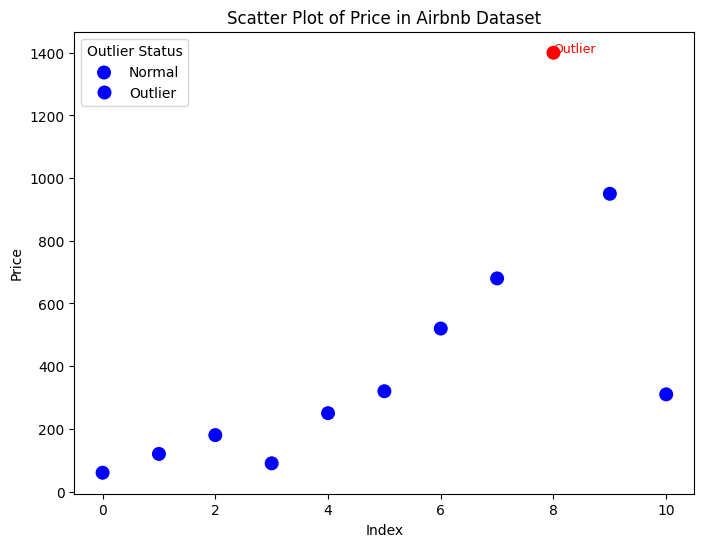

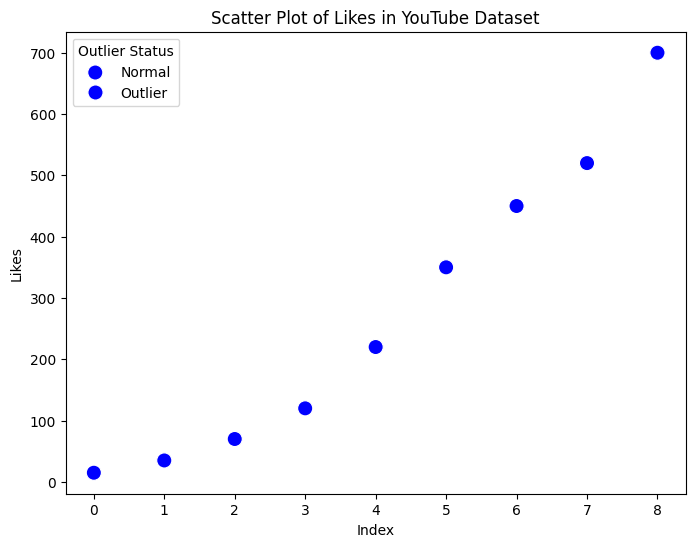

In [40]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Modified Airbnb dataset
airbnb_data = pd.DataFrame({
    "price": [60, 120, 180, 90, 250, 320, 520, 680, 1400, 950, 310],
    "other_feature": [1.2, 2.1, 1.6, 3.2, 2.7, 4.1, 5.3, 3.8, 6.2, 4.7, 2.4]
})

# Modified YouTube dataset
youtube_data = pd.DataFrame({
    "likes": [15, 35, 70, 120, 220, 350, 450, 520, 700],
    "other_feature": [1.1, 1.3, 1.5, 1.7, 1.9, 2.1, 2.3, 2.5, 2.7]
})

def visualize_outliers_scatter(df, feature, dataset_name):

    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)

    iqr = q3 - q1

    outlier_condition = (df[feature] < (q1 - 1.5 * iqr)) | \
                        (df[feature] > (q3 + 1.5 * iqr))

    plt.figure(figsize=(8,6))

    sns.scatterplot(
        x=df.index,
        y=feature,
        data=df,
        hue=outlier_condition,
        palette={True: "red", False: "blue"},
        s=120
    )

    # Label outliers
    for i in range(len(df)):
        if outlier_condition.iloc[i]:
            plt.text(
                df.index[i],
                df[feature].iloc[i],
                "Outlier",
                color="red",
                fontsize=9,
                ha="left"
            )

    plt.title(f"Scatter Plot of {feature.capitalize()} in {dataset_name} Dataset")
    plt.xlabel("Index")
    plt.ylabel(feature.capitalize())

    plt.legend(title="Outlier Status", labels=["Normal", "Outlier"])
    plt.show()


# Visualize outliers for Airbnb dataset
visualize_outliers_scatter(airbnb_data, "price", "Airbnb")

# Visualize outliers for YouTube dataset
visualize_outliers_scatter(youtube_data, "likes", "YouTube")